# Unified Comparison: ARIMA vs LSTM vs LSTM-SGARCH

This notebook compares the latest compatible run artifacts for ARIMA, standalone LSTM, and hybrid LSTM-SGARCH. It reports forecast metrics, rolling-window metrics, and strategy metrics.


In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

In [2]:
TIMESTAMP_COL = 'timestamp_utc'
TARGET_COL = 'target_daily_log_return'

RAW_5MIN_PATH = Path('data/BTC/BTC_USD_coinbase_spot_5min.csv')
ARIMA_NOTEBOOK_PATH = Path('ARIMA_modeling.ipynb')
ARIMA_META_PATH = Path('artifacts/arima_daily_return/arima_model_metadata.json')

LSTM_ARTIFACTS_ROOT = Path('artifacts/lstm_walk_forward')
HYBRID_ARTIFACTS_ROOT = Path('artifacts/lstm_sgarch_walk_forward')

OUT_DIR = Path('artifacts/model_comparison_daily')
OUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_WINDOW_DAYS = 180
ROLLING_WINDOWS = [5, 7, 10]
EPS = 1e-12
TRADING_DAYS = 365
TRANSACTION_COST_BPS = 5.0

for p in [RAW_5MIN_PATH, ARIMA_NOTEBOOK_PATH]:
    if not p.exists():
        raise FileNotFoundError(f'Missing required file: {p}')


In [3]:
def resolve_latest_run(root: Path) -> dict:
    pointer = root / 'latest_run.json'
    if not pointer.exists():
        raise FileNotFoundError(f'Missing latest run pointer: {pointer}. Run the related notebook first.')
    metadata = json.loads(pointer.read_text(encoding='utf-8'))
    run_dir = Path(metadata['run_dir'])
    if not run_dir.exists():
        raise FileNotFoundError(f'Latest run directory does not exist: {run_dir}')
    metadata['run_dir_path'] = run_dir
    return metadata


def extract_arima_config_from_notebook(notebook_path: Path, metadata_path: Path = ARIMA_META_PATH) -> dict:
    if metadata_path.exists():
        metadata = json.loads(metadata_path.read_text(encoding='utf-8'))
        order = metadata.get('selected_order', metadata.get('order'))
        if isinstance(order, dict):
            return {'p': int(order['p']), 'd': int(order['d']), 'q': int(order['q']), 'trend': str(metadata.get('trend', 'c')), 'source': str(metadata_path)}
        if isinstance(order, (list, tuple)) and len(order) == 3:
            return {'p': int(order[0]), 'd': int(order[1]), 'q': int(order[2]), 'trend': str(metadata.get('trend', 'c')), 'source': str(metadata_path)}
    nb = json.loads(notebook_path.read_text(encoding='utf-8'))
    pattern = re.compile(r'Selected ARIMA\((\d+),\s*(\d+),\s*(\d+)\), trend=([A-Za-z0-9_+-]+)')
    for cell in nb.get('cells', []):
        if cell.get('cell_type') != 'code':
            continue
        for output in cell.get('outputs', []):
            text_parts = []
            if isinstance(output.get('text'), list):
                text_parts.extend(output['text'])
            elif isinstance(output.get('text'), str):
                text_parts.append(output['text'])
            data = output.get('data', {}) if isinstance(output, dict) else {}
            if isinstance(data, dict):
                txt = data.get('text/plain')
                if isinstance(txt, list):
                    text_parts.extend(txt)
                elif isinstance(txt, str):
                    text_parts.append(txt)
            blob = '\n'.join(text_parts)
            m = pattern.search(blob)
            if m:
                return {'p': int(m.group(1)), 'd': int(m.group(2)), 'q': int(m.group(3)), 'trend': str(m.group(4)), 'source': str(notebook_path)}
    raise RuntimeError('ARIMA configuration was not found. Run ARIMA_modeling.ipynb so it writes metadata or output with selected ARIMA order.')


def build_daily_target_frame(raw_5m_path: Path) -> pd.DataFrame:
    raw = pd.read_csv(raw_5m_path)
    raw[TIMESTAMP_COL] = pd.to_datetime(raw[TIMESTAMP_COL], utc=True)
    raw = raw.sort_values(TIMESTAMP_COL).drop_duplicates(TIMESTAMP_COL, keep='last').reset_index(drop=True)
    raw['log_close_5m'] = np.log(raw['close'])
    raw['intraday_log_return'] = raw['log_close_5m'].diff()
    raw_idx = raw.set_index(TIMESTAMP_COL)
    daily = raw_idx.resample('1D', closed='left', label='left').agg(close=('close', 'last'))
    daily['log_close'] = np.log(daily['close'])
    daily[TARGET_COL] = daily['log_close'].diff()
    return daily.reset_index()[[TIMESTAMP_COL, TARGET_COL]].replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)


def model_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    err = y_pred - y_true
    denom = np.abs(y_true) + np.abs(y_pred) + EPS
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    mape = float(np.mean(np.abs(err) / (np.abs(y_true) + EPS)) * 100.0)
    smape = float(np.mean(2.0 * np.abs(err) / denom) * 100.0)
    sst = float(np.sum((y_true - y_true.mean()) ** 2))
    sse = float(np.sum(err ** 2))
    r2 = float(1.0 - sse / sst) if sst > EPS else float('nan')
    corr = float(np.corrcoef(y_true, y_pred)[0, 1]) if (np.std(y_true) > EPS and np.std(y_pred) > EPS) else float('nan')
    direction_acc = float(np.mean(np.sign(y_true) == np.sign(y_pred)))
    return {'rmse': rmse, 'mae': mae, 'mape_pct': mape, 'smape_pct': smape, 'r2': r2, 'correlation': corr, 'direction_accuracy': direction_acc}


def strategy_metrics(returns: np.ndarray, turnover: np.ndarray) -> dict:
    returns = np.asarray(returns, dtype=float)
    turnover = np.asarray(turnover, dtype=float)
    equity = np.exp(np.cumsum(returns))
    drawdown = equity / np.maximum.accumulate(equity) - 1.0
    vol = float(np.std(returns, ddof=1) * np.sqrt(TRADING_DAYS)) if len(returns) > 1 else float('nan')
    ann_return = float(np.exp(np.mean(returns) * TRADING_DAYS) - 1.0)
    sharpe = float((np.mean(returns) / (np.std(returns, ddof=1) + EPS)) * np.sqrt(TRADING_DAYS)) if len(returns) > 1 else float('nan')
    downside = returns[returns < 0]
    sortino = float((np.mean(returns) / (np.std(downside, ddof=1) + EPS)) * np.sqrt(TRADING_DAYS)) if len(downside) > 1 else float('nan')
    return {'total_return': float(equity[-1] - 1.0), 'annualized_return': ann_return, 'annualized_volatility': vol, 'sharpe': sharpe, 'sortino': sortino, 'max_drawdown': float(np.min(drawdown)), 'hit_rate': float(np.mean(returns > 0)), 'turnover': float(np.mean(turnover))}


In [4]:
# Build target frame and load latest compatible prediction artifacts
df = build_daily_target_frame(RAW_5MIN_PATH)
lstm_latest = resolve_latest_run(LSTM_ARTIFACTS_ROOT)
hybrid_latest = resolve_latest_run(HYBRID_ARTIFACTS_ROOT)

LSTM_META_PATH = Path(lstm_latest['best_model_metadata_path'])
LSTM_PRED_PATH = Path(lstm_latest['test_predictions_path'])
HYBRID_META_PATH = Path(hybrid_latest['best_model_metadata_path'])
HYBRID_PRED_PATH = Path(hybrid_latest['test_predictions_path'])

for p in [LSTM_META_PATH, LSTM_PRED_PATH, HYBRID_META_PATH, HYBRID_PRED_PATH]:
    if not p.exists():
        raise FileNotFoundError(f'Missing required artifact: {p}')

with LSTM_META_PATH.open('r', encoding='utf-8') as f:
    lstm_meta = json.load(f)
with HYBRID_META_PATH.open('r', encoding='utf-8') as f:
    hybrid_meta = json.load(f)

if hybrid_meta.get('lstm_run_config_signature') != lstm_meta.get('run_config_signature'):
    raise RuntimeError('Hybrid run does not reference the latest LSTM run. Rerun LSTM_SGARCH_5min_walk_forward.ipynb after LSTM.')

lstm_df = pd.read_csv(LSTM_PRED_PATH)
lstm_df[TIMESTAMP_COL] = pd.to_datetime(lstm_df[TIMESTAMP_COL], utc=True)
lstm_df = lstm_df.rename(columns={'y_true': 'y_true_lstm', 'y_pred': 'lstm_pred'})

hybrid_df = pd.read_csv(HYBRID_PRED_PATH)
hybrid_df[TIMESTAMP_COL] = pd.to_datetime(hybrid_df[TIMESTAMP_COL], utc=True)
hybrid_df = hybrid_df.rename(columns={'y_true': 'y_true_hybrid', 'lstm_mean_pred': 'lstm_sgarch_pred'})

base = lstm_df[[TIMESTAMP_COL, 'fold_id', 'y_true_lstm', 'lstm_pred']].merge(
    hybrid_df[[TIMESTAMP_COL, 'y_true_hybrid', 'lstm_sgarch_pred', 'sgarch_vol_pred']],
    on=TIMESTAMP_COL,
    how='inner',
)
if base.empty:
    raise RuntimeError('No overlapping timestamps between LSTM and LSTM-SGARCH predictions')
if not np.allclose(base['y_true_lstm'].to_numpy(), base['y_true_hybrid'].to_numpy(), atol=1e-12):
    raise RuntimeError('Mismatch between LSTM and LSTM-SGARCH y_true values')
base = base.rename(columns={'y_true_lstm': 'y_true'}).drop(columns=['y_true_hybrid'])
base = base.sort_values([TIMESTAMP_COL, 'fold_id']).reset_index(drop=True)

print('LSTM run:', lstm_meta.get('run_config_signature'))
print('Hybrid run:', hybrid_meta.get('run_config_signature'))
print('LSTM best params:', lstm_meta['best_params'])
print('LSTM-SGARCH best params:', hybrid_meta['best_params'])
print('Aligned rows:', len(base))
base.head()


LSTM run: 60536b3ea525
Hybrid run: 0faa02bca6ee
LSTM best params: {'seq_len': 10, 'lstm_units': 32, 'dropout': 0.2, 'learning_rate': 0.0002, 'batch_size': 64}
LSTM-SGARCH best params: {'seq_len': 10, 'lstm_units': 32, 'dropout': 0.2, 'learning_rate': 0.0002, 'batch_size': 64}
Aligned rows: 30


,timestamp_utc,fold_id,y_true,lstm_pred,lstm_sgarch_pred,sgarch_vol_pred
0,2026-03-13 00:00:00+00:00,0,0.005835,0.213137,0.213137,0.249537
1,2026-03-14 00:00:00+00:00,0,0.004047,0.029953,0.029953,0.240615
2,2026-03-15 00:00:00+00:00,0,0.022186,-0.016286,-0.016286,0.225506
3,2026-03-16 00:00:00+00:00,1,0.027845,-0.109338,-0.109338,0.253824
4,2026-03-17 00:00:00+00:00,1,-0.012799,-0.075907,-0.075907,0.226492


In [5]:
# ARIMA from the daily-return benchmark notebook + walk-forward on the same fold timestamps
arima_cfg = extract_arima_config_from_notebook(ARIMA_NOTEBOOK_PATH, ARIMA_META_PATH)
print('ARIMA config from notebook:', arima_cfg)

target_by_ts = df.set_index(TIMESTAMP_COL)[TARGET_COL].astype(float)
arima_rows = []
for fold_id, fold_df in base.groupby('fold_id', sort=True):
    fold_df = fold_df.sort_values(TIMESTAMP_COL)
    eval_ts = fold_df[TIMESTAMP_COL].tolist()
    eval_start = eval_ts[0]
    train_end = eval_start
    train_start = train_end - pd.Timedelta(days=TRAIN_WINDOW_DAYS)
    train_series = target_by_ts[(target_by_ts.index >= train_start) & (target_by_ts.index < train_end)]
    if len(train_series) < 10:
        raise RuntimeError(f'Not enough ARIMA train observations for fold {fold_id}: {len(train_series)}')
    state = ARIMA(train_series.to_numpy(dtype=float), order=(arima_cfg['p'], arima_cfg['d'], arima_cfg['q']), trend=arima_cfg['trend'], enforce_stationarity=False, enforce_invertibility=False).fit()
    for ts in eval_ts:
        pred = float(state.forecast(steps=1)[0])
        actual = float(target_by_ts.loc[ts])
        arima_rows.append({TIMESTAMP_COL: ts, 'fold_id': int(fold_id), 'arima_pred': pred, 'y_true_arima': actual})
        state = state.append([actual], refit=False)

arima_df = pd.DataFrame(arima_rows).sort_values([TIMESTAMP_COL, 'fold_id']).reset_index(drop=True)
comp = base.merge(arima_df[[TIMESTAMP_COL, 'fold_id', 'arima_pred', 'y_true_arima']], on=[TIMESTAMP_COL, 'fold_id'], how='inner')
if comp.empty:
    raise RuntimeError('No overlap after merging ARIMA predictions')
if not np.allclose(comp['y_true'].to_numpy(), comp['y_true_arima'].to_numpy(), atol=1e-12):
    raise RuntimeError('ARIMA y_true mismatch on aligned rows')
comp = comp.drop(columns=['y_true_arima']).sort_values([TIMESTAMP_COL, 'fold_id']).reset_index(drop=True)
with (OUT_DIR / 'arima_model_from_notebook.json').open('w', encoding='utf-8') as f:
    json.dump(arima_cfg, f, indent=2)
comp.head()


ARIMA config from notebook: {'p': 1, 'd': 0, 'q': 0, 'trend': 'c', 'source': 'ARIMA_modeling.ipynb'}


,timestamp_utc,fold_id,y_true,lstm_pred,lstm_sgarch_pred,sgarch_vol_pred,arima_pred
0,2026-03-13 00:00:00+00:00,0,0.005835,0.213137,0.213137,0.249537,-0.003350
1,2026-03-14 00:00:00+00:00,0,0.004047,0.029953,0.029953,0.240615,-0.003450
2,2026-03-15 00:00:00+00:00,0,0.022186,-0.016286,-0.016286,0.225506,-0.003305
3,2026-03-16 00:00:00+00:00,1,0.027845,-0.109338,-0.109338,0.253824,-0.004589
4,2026-03-17 00:00:00+00:00,1,-0.012799,-0.075907,-0.075907,0.226492,-0.005035


In [6]:
# Forecast metrics, rolling-window metrics, and strategy metrics
models = {'ARIMA': comp['arima_pred'].to_numpy(dtype=float), 'LSTM': comp['lstm_pred'].to_numpy(dtype=float), 'LSTM-SGARCH': comp['lstm_sgarch_pred'].to_numpy(dtype=float)}
y_true = comp['y_true'].to_numpy(dtype=float)

overall_df = pd.DataFrame([{'model': name, **model_metrics(y_true, pred)} for name, pred in models.items()]).sort_values('rmse').reset_index(drop=True)

rolling_rows = []
for w in ROLLING_WINDOWS:
    for i in range(w - 1, len(comp)):
        ys = y_true[i - w + 1:i + 1]
        ts = comp.loc[i, TIMESTAMP_COL]
        for name, pred in models.items():
            ps = pred[i - w + 1:i + 1]
            rolling_rows.append({TIMESTAMP_COL: ts, 'window': int(w), 'model': name, **model_metrics(ys, ps)})
rolling_df = pd.DataFrame(rolling_rows)

transaction_cost = TRANSACTION_COST_BPS / 10_000
strategy_df = comp[[TIMESTAMP_COL, 'y_true', 'arima_pred', 'lstm_pred', 'lstm_sgarch_pred', 'sgarch_vol_pred']].copy()
strategy_df['BuyHold_position'] = 1.0
strategy_df['ARIMA_position'] = np.sign(strategy_df['arima_pred']).replace(0, 0.0)
strategy_df['LSTM_position'] = np.sign(strategy_df['lstm_pred']).replace(0, 0.0)
hybrid_z = strategy_df['lstm_sgarch_pred'] / (strategy_df['sgarch_vol_pred'].abs() + EPS)
strategy_df['LSTM-SGARCH_position'] = np.clip(hybrid_z, -1.0, 1.0)

strategy_rows = []
for name in ['BuyHold', 'ARIMA', 'LSTM', 'LSTM-SGARCH']:
    pos_col = f'{name}_position'
    gross_col = f'{name}_gross_return'
    net_col = f'{name}_strategy_return'
    turnover_col = f'{name}_turnover'
    strategy_df[turnover_col] = strategy_df[pos_col].diff().abs().fillna(strategy_df[pos_col].abs())
    strategy_df[gross_col] = strategy_df[pos_col] * strategy_df['y_true']
    strategy_df[net_col] = strategy_df[gross_col] - transaction_cost * strategy_df[turnover_col]
    strategy_rows.append({'strategy': name, **strategy_metrics(strategy_df[net_col].to_numpy(dtype=float), strategy_df[turnover_col].to_numpy(dtype=float)), 'transaction_cost_bps': TRANSACTION_COST_BPS})
strategy_metrics_df = pd.DataFrame(strategy_rows).sort_values('sharpe', ascending=False).reset_index(drop=True)

comp.to_csv(OUT_DIR / 'test_predictions_aligned.csv', index=False)
overall_df.to_csv(OUT_DIR / 'overall_metrics.csv', index=False)
rolling_df.to_csv(OUT_DIR / 'rolling_window_metrics.csv', index=False)
strategy_df.to_csv(OUT_DIR / 'strategy_returns.csv', index=False)
strategy_metrics_df.to_csv(OUT_DIR / 'strategy_metrics.csv', index=False)

print('Saved comparison artifacts to:', OUT_DIR)
display(overall_df)
display(strategy_metrics_df)


Saved comparison artifacts to: artifacts/model_comparison_daily


,model,rmse,mae,mape_pct,smape_pct,r2,correlation,direction_accuracy
0,ARIMA,0.021301,0.016755,127.659338,161.694512,-0.074586,-0.154868,0.466667
1,LSTM,0.140321,0.121692,3054.705072,175.470782,-45.630462,0.191355,0.600000
2,LSTM-SGARCH,0.140321,0.121692,3054.705072,175.470782,-45.630462,0.191355,0.600000


,strategy,total_return,annualized_return,annualized_volatility,sharpe,sortino,max_drawdown,hit_rate,turnover,transaction_cost_bps
0,LSTM-SGARCH,0.140085,3.928768,0.301134,5.296941,11.181982,-0.029709,0.566667,0.367887,5.0
1,LSTM,0.107283,2.455244,0.395140,3.137856,5.538991,-0.049751,0.600000,0.433333,5.0
2,BuyHold,0.035699,0.532292,0.399227,1.068978,1.716634,-0.119241,0.533333,0.033333,5.0
3,ARIMA,-0.035434,-0.355275,0.399374,-1.099050,-1.693351,-0.097543,0.466667,0.033333,5.0


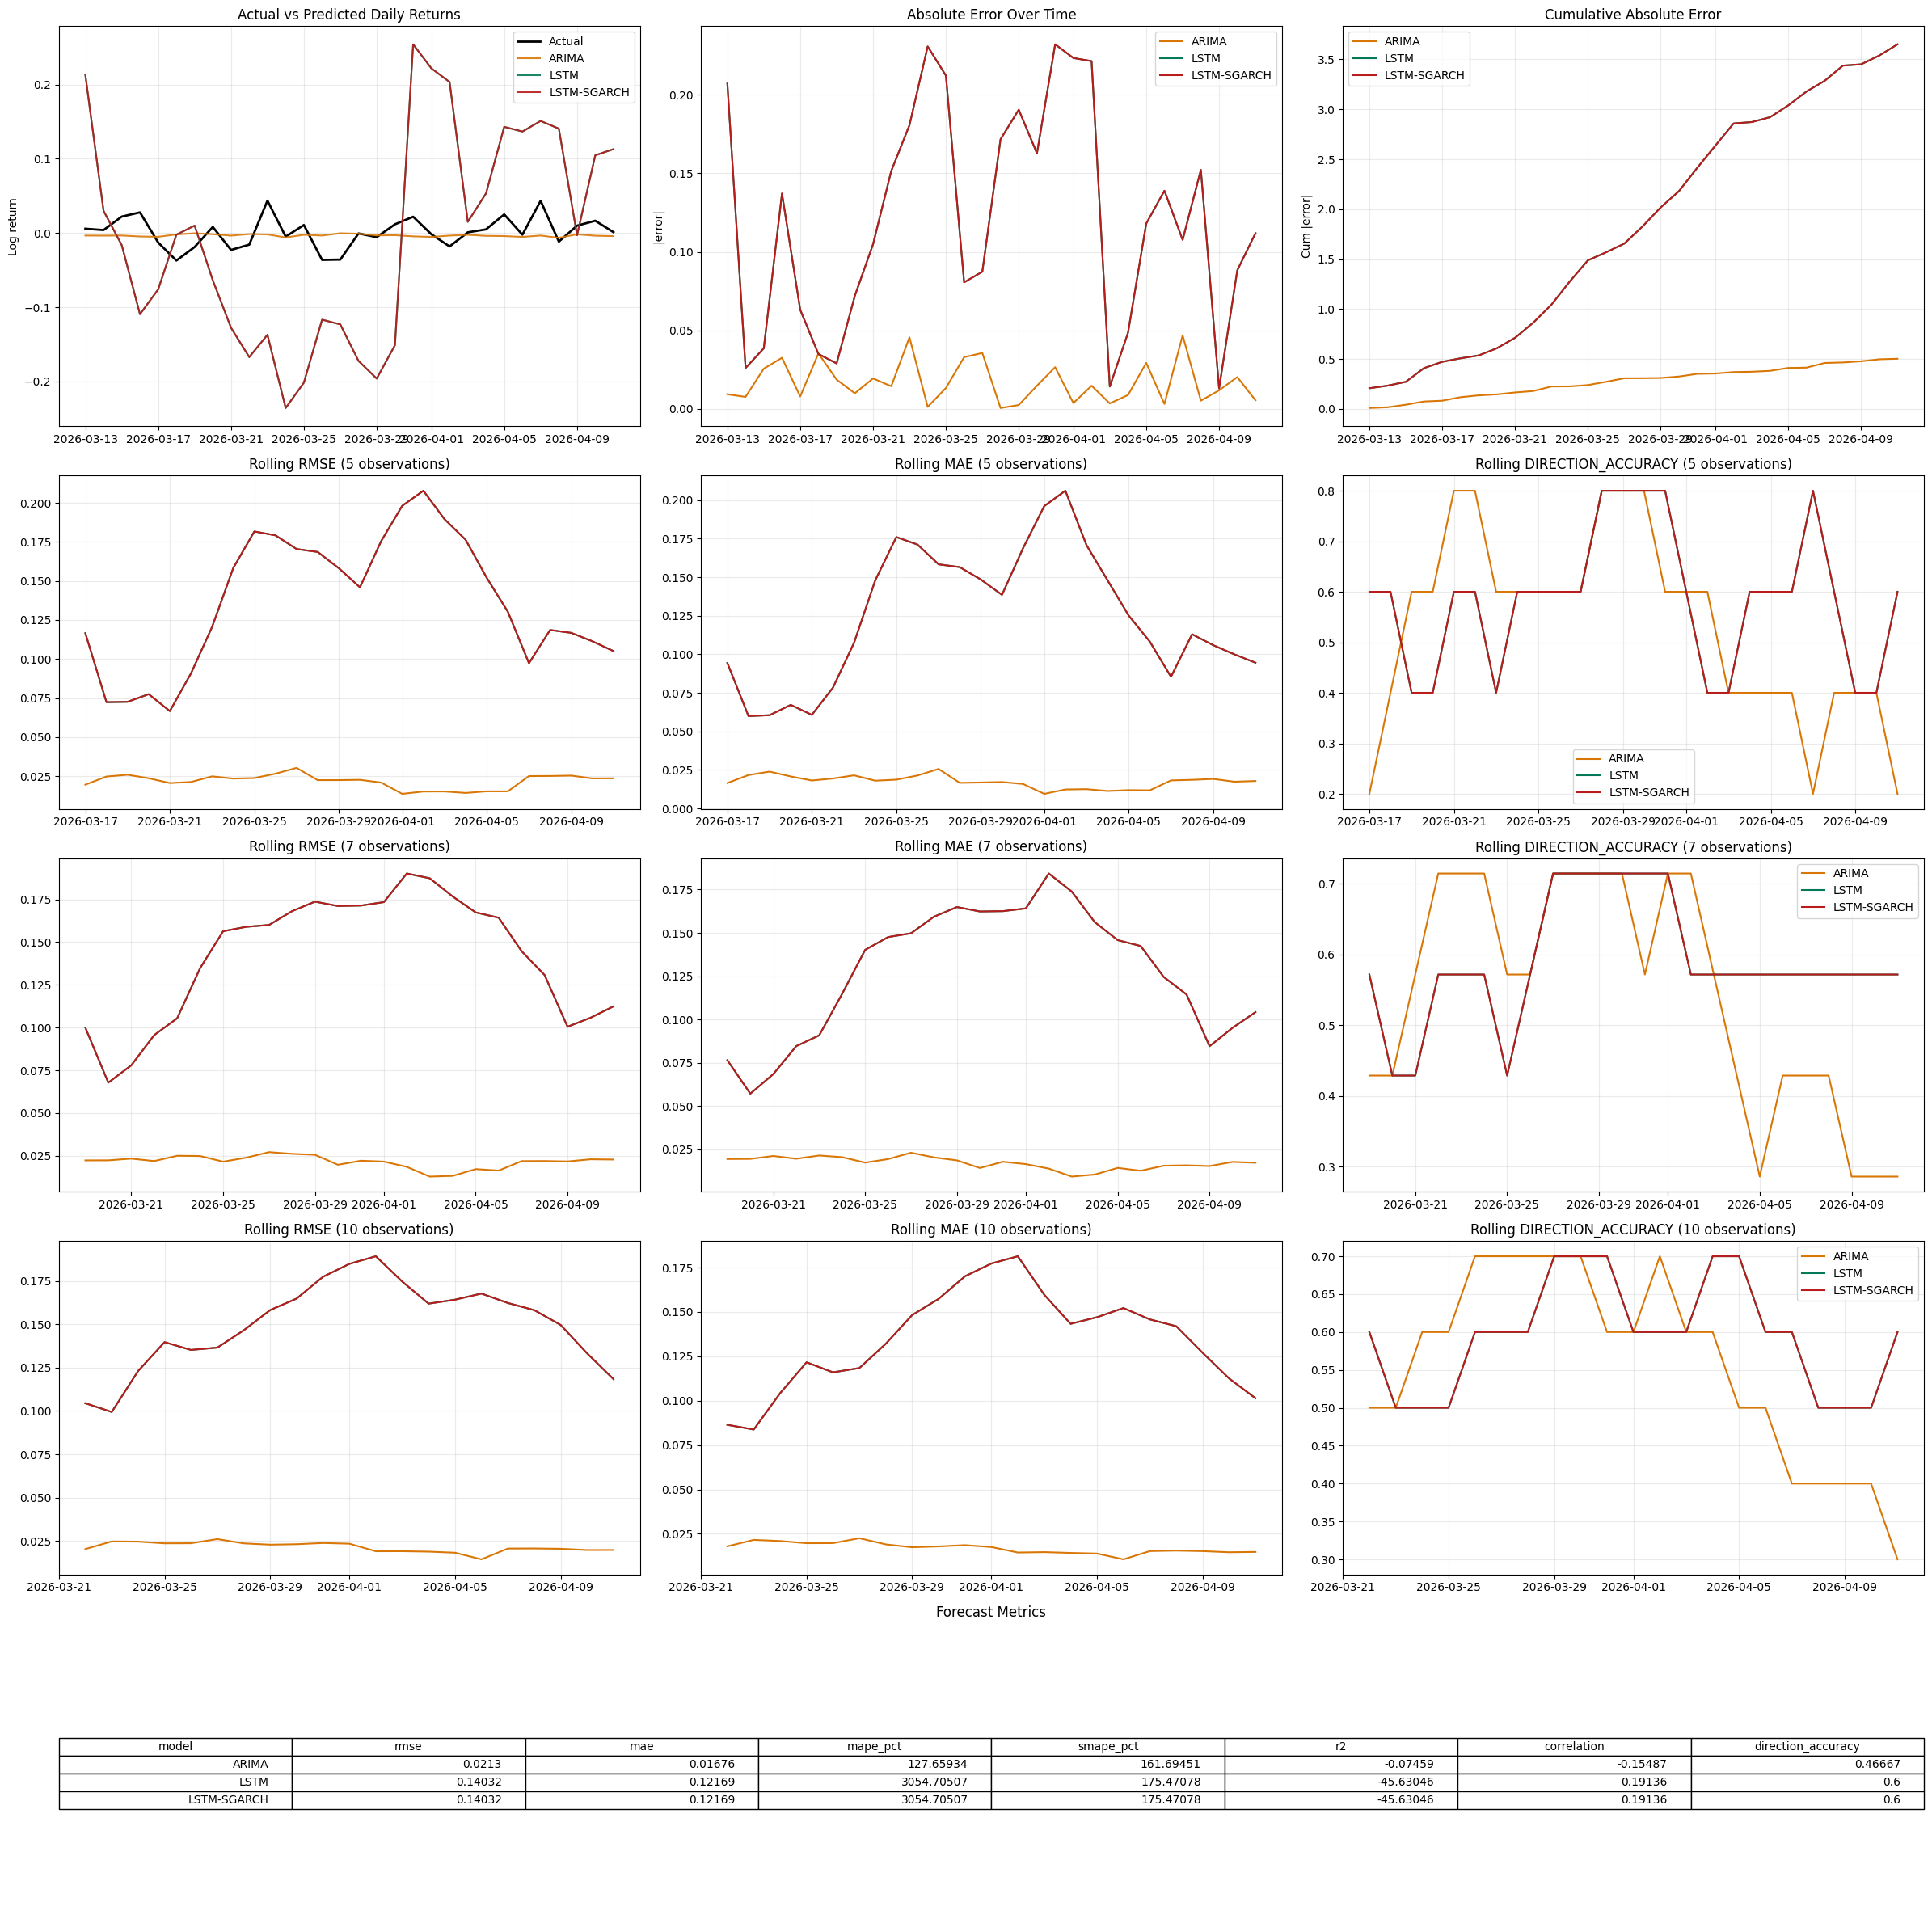

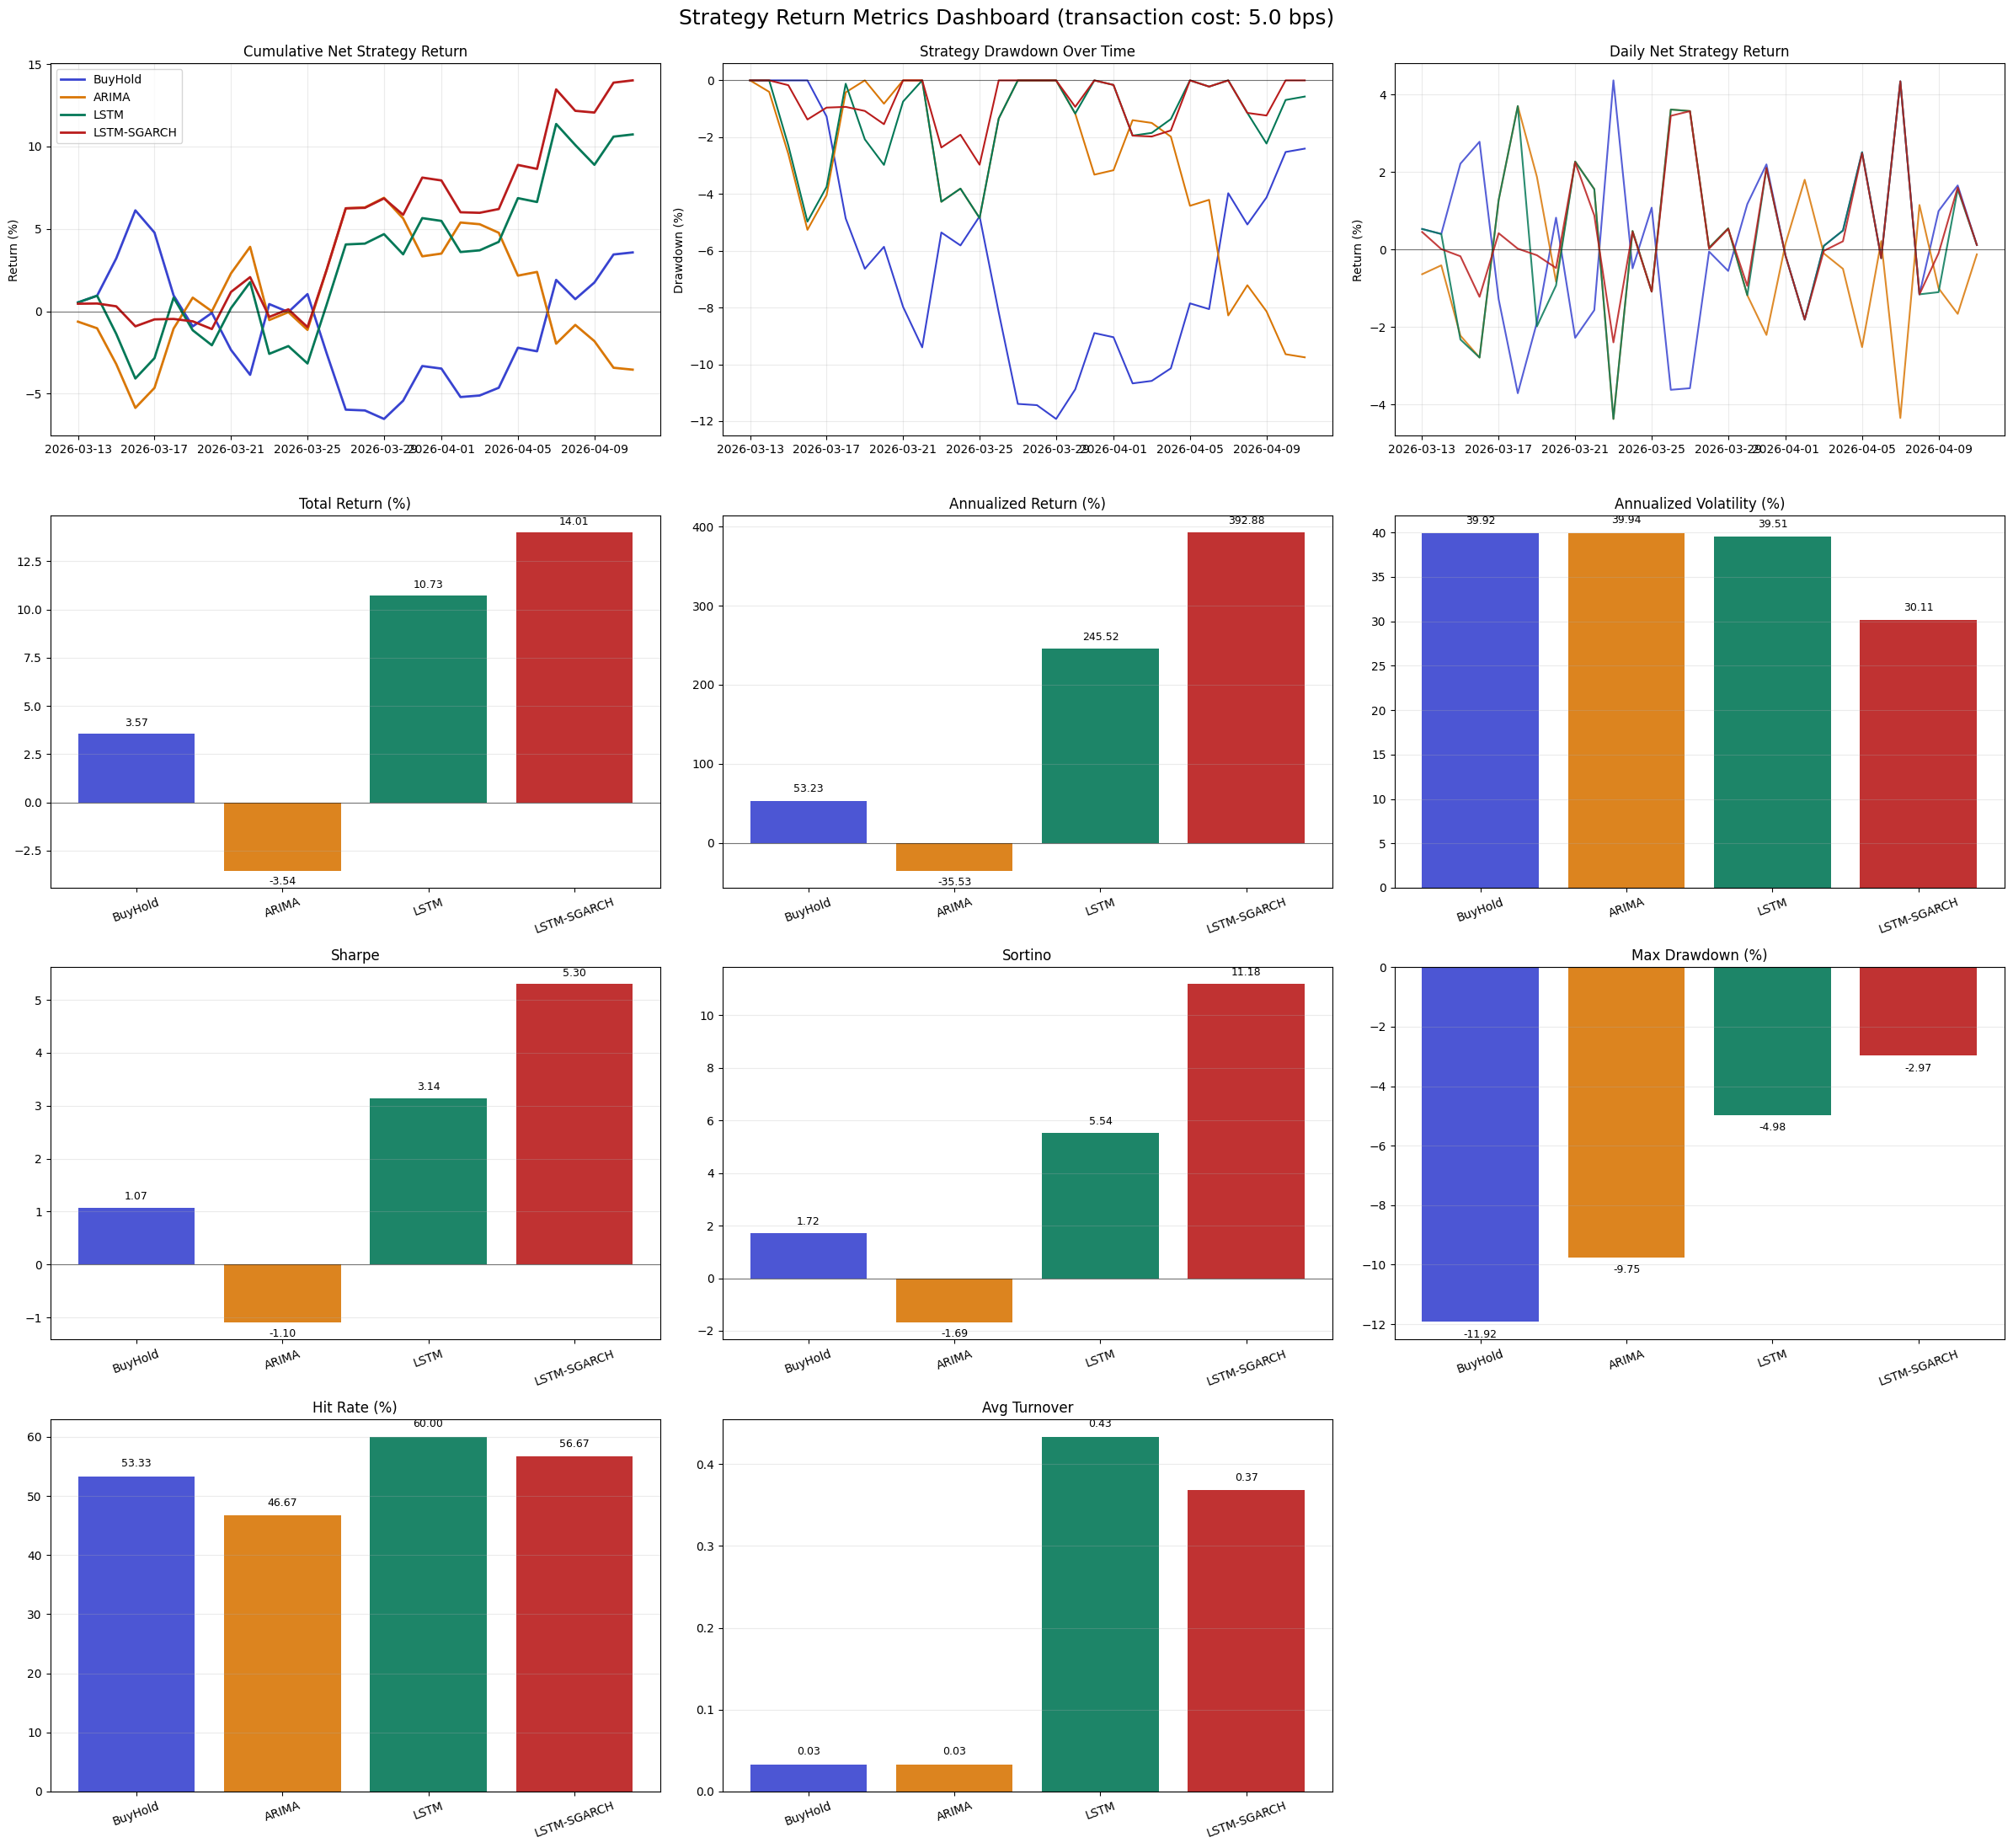

,strategy,total_return,annualized_return,annualized_volatility,sharpe,sortino,max_drawdown,hit_rate,turnover,transaction_cost_bps
0,LSTM-SGARCH,0.140085,3.928768,0.301134,5.296941,11.181982,-0.029709,0.566667,0.367887,5.0
1,LSTM,0.107283,2.455244,0.395140,3.137856,5.538991,-0.049751,0.600000,0.433333,5.0
2,BuyHold,0.035699,0.532292,0.399227,1.068978,1.716634,-0.119241,0.533333,0.033333,5.0
3,ARIMA,-0.035434,-0.355275,0.399374,-1.099050,-1.693351,-0.097543,0.466667,0.033333,5.0


Saved dashboard figures:
artifacts/model_comparison_daily/forecast_model_comparison_dashboard.png
artifacts/model_comparison_daily/strategy_return_metrics_dashboard.png


In [7]:
# Forecast dashboard plus strategy return-metric dashboard
plot_df = comp.copy().sort_values(TIMESTAMP_COL)
plot_df[TIMESTAMP_COL] = pd.to_datetime(plot_df[TIMESTAMP_COL], utc=True)

MODEL_COLORS = {
    'BuyHold': '#3843D0',
    'ARIMA': '#D97706',
    'LSTM': '#047857',
    'LSTM-SGARCH': '#B91C1C',
}
PREDICTION_COLS = {
    'ARIMA': 'arima_pred',
    'LSTM': 'lstm_pred',
    'LSTM-SGARCH': 'lstm_sgarch_pred',
}
STRATEGY_NAMES = ['BuyHold', 'ARIMA', 'LSTM', 'LSTM-SGARCH']

fig = plt.figure(figsize=(24, 24))
gs = fig.add_gridspec(5, 3, height_ratios=[1.2, 1.0, 1.0, 1.0, 0.9])
ax_pred = fig.add_subplot(gs[0, 0])
ax_abs = fig.add_subplot(gs[0, 1])
ax_cum = fig.add_subplot(gs[0, 2])

ax_pred.plot(plot_df[TIMESTAMP_COL], plot_df['y_true'], label='Actual', color='black', linewidth=2.0)
for name, col in PREDICTION_COLS.items():
    ax_pred.plot(plot_df[TIMESTAMP_COL], plot_df[col], label=name, alpha=0.9, color=MODEL_COLORS[name])
    ax_abs.plot(plot_df[TIMESTAMP_COL], np.abs(plot_df[col] - plot_df['y_true']), label=name, color=MODEL_COLORS[name])
    ax_cum.plot(plot_df[TIMESTAMP_COL], np.cumsum(np.abs(plot_df[col] - plot_df['y_true'])), label=name, color=MODEL_COLORS[name])

ax_pred.set_title('Actual vs Predicted Daily Returns')
ax_pred.set_ylabel('Log return')
ax_pred.grid(alpha=0.25)
ax_pred.legend()
ax_abs.set_title('Absolute Error Over Time')
ax_abs.set_ylabel('|error|')
ax_abs.grid(alpha=0.25)
ax_abs.legend()
ax_cum.set_title('Cumulative Absolute Error')
ax_cum.set_ylabel('Cum |error|')
ax_cum.grid(alpha=0.25)
ax_cum.legend()

for r, w in enumerate(ROLLING_WINDOWS, start=1):
    rw = rolling_df[rolling_df['window'] == w].copy()
    rw[TIMESTAMP_COL] = pd.to_datetime(rw[TIMESTAMP_COL], utc=True)
    for c, metric in enumerate(['rmse', 'mae', 'direction_accuracy']):
        ax = fig.add_subplot(gs[r, c])
        for name in PREDICTION_COLS:
            part = rw[rw['model'] == name].sort_values(TIMESTAMP_COL)
            ax.plot(part[TIMESTAMP_COL], part[metric], label=name, color=MODEL_COLORS[name])
        ax.set_title(f'Rolling {metric.upper()} ({w} observations)')
        ax.grid(alpha=0.25)
        if c == 2:
            ax.legend()

ax_table = fig.add_subplot(gs[4, :])
ax_table.axis('off')
ax_table.set_title('Forecast Metrics')
forecast_table = overall_df.round(5)
ax_table.table(cellText=forecast_table.values, colLabels=forecast_table.columns, loc='center')
fig.tight_layout()
fig.savefig(OUT_DIR / 'forecast_model_comparison_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

# Strategy return tracking: all return and risk metrics are plotted, not only shown in a table.
strategy_plot_df = strategy_df.copy().sort_values(TIMESTAMP_COL)
strategy_plot_df[TIMESTAMP_COL] = pd.to_datetime(strategy_plot_df[TIMESTAMP_COL], utc=True)
strategy_metric_order = [
    'total_return',
    'annualized_return',
    'annualized_volatility',
    'sharpe',
    'sortino',
    'max_drawdown',
    'hit_rate',
    'turnover',
]
strategy_metric_labels = {
    'total_return': 'Total Return (%)',
    'annualized_return': 'Annualized Return (%)',
    'annualized_volatility': 'Annualized Volatility (%)',
    'sharpe': 'Sharpe',
    'sortino': 'Sortino',
    'max_drawdown': 'Max Drawdown (%)',
    'hit_rate': 'Hit Rate (%)',
    'turnover': 'Avg Turnover',
}
percent_metrics = {'total_return', 'annualized_return', 'annualized_volatility', 'max_drawdown', 'hit_rate'}
strategy_metric_plot = strategy_metrics_df.set_index('strategy').reindex(STRATEGY_NAMES)

strategy_fig, axes = plt.subplots(4, 3, figsize=(24, 22))
axes = axes.ravel()

ax = axes[0]
for name in STRATEGY_NAMES:
    ret = strategy_plot_df[f'{name}_strategy_return'].to_numpy(dtype=float)
    equity = np.exp(np.cumsum(ret)) - 1.0
    ax.plot(strategy_plot_df[TIMESTAMP_COL], equity * 100.0, label=name, color=MODEL_COLORS[name], linewidth=2.0)
ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
ax.set_title('Cumulative Net Strategy Return')
ax.set_ylabel('Return (%)')
ax.grid(alpha=0.25)
ax.legend()

ax = axes[1]
for name in STRATEGY_NAMES:
    ret = strategy_plot_df[f'{name}_strategy_return'].to_numpy(dtype=float)
    equity = np.exp(np.cumsum(ret))
    drawdown = equity / np.maximum.accumulate(equity) - 1.0
    ax.plot(strategy_plot_df[TIMESTAMP_COL], drawdown * 100.0, label=name, color=MODEL_COLORS[name])
ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
ax.set_title('Strategy Drawdown Over Time')
ax.set_ylabel('Drawdown (%)')
ax.grid(alpha=0.25)

ax = axes[2]
for name in STRATEGY_NAMES:
    ax.plot(strategy_plot_df[TIMESTAMP_COL], strategy_plot_df[f'{name}_strategy_return'] * 100.0, label=name, color=MODEL_COLORS[name], alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
ax.set_title('Daily Net Strategy Return')
ax.set_ylabel('Return (%)')
ax.grid(alpha=0.25)

bar_axes = axes[3:]
for metric, ax in zip(strategy_metric_order, bar_axes):
    values = strategy_metric_plot[metric].astype(float)
    plot_values = values * 100.0 if metric in percent_metrics else values
    colors = [MODEL_COLORS[name] for name in strategy_metric_plot.index]
    bars = ax.bar(strategy_metric_plot.index, plot_values, color=colors, alpha=0.9)
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
    ax.set_title(strategy_metric_labels[metric])
    ax.grid(axis='y', alpha=0.25)
    ax.tick_params(axis='x', rotation=20)
    for bar in bars:
        height = bar.get_height()
        offset = 0.02 * (np.nanmax(np.abs(plot_values.to_numpy(dtype=float))) + EPS)
        y = height + offset if height >= 0 else height - offset
        ax.text(bar.get_x() + bar.get_width() / 2, y, f'{height:.2f}', ha='center', va='bottom' if height >= 0 else 'top', fontsize=9)

for ax in axes[len(strategy_metric_order) + 3:]:
    ax.axis('off')

strategy_fig.suptitle(f'Strategy Return Metrics Dashboard (transaction cost: {TRANSACTION_COST_BPS:.1f} bps)', fontsize=18, y=0.995)
strategy_fig.tight_layout()
strategy_fig.savefig(OUT_DIR / 'strategy_return_metrics_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

display(strategy_metrics_df)
print('Saved dashboard figures:')
print(OUT_DIR / 'forecast_model_comparison_dashboard.png')
print(OUT_DIR / 'strategy_return_metrics_dashboard.png')
